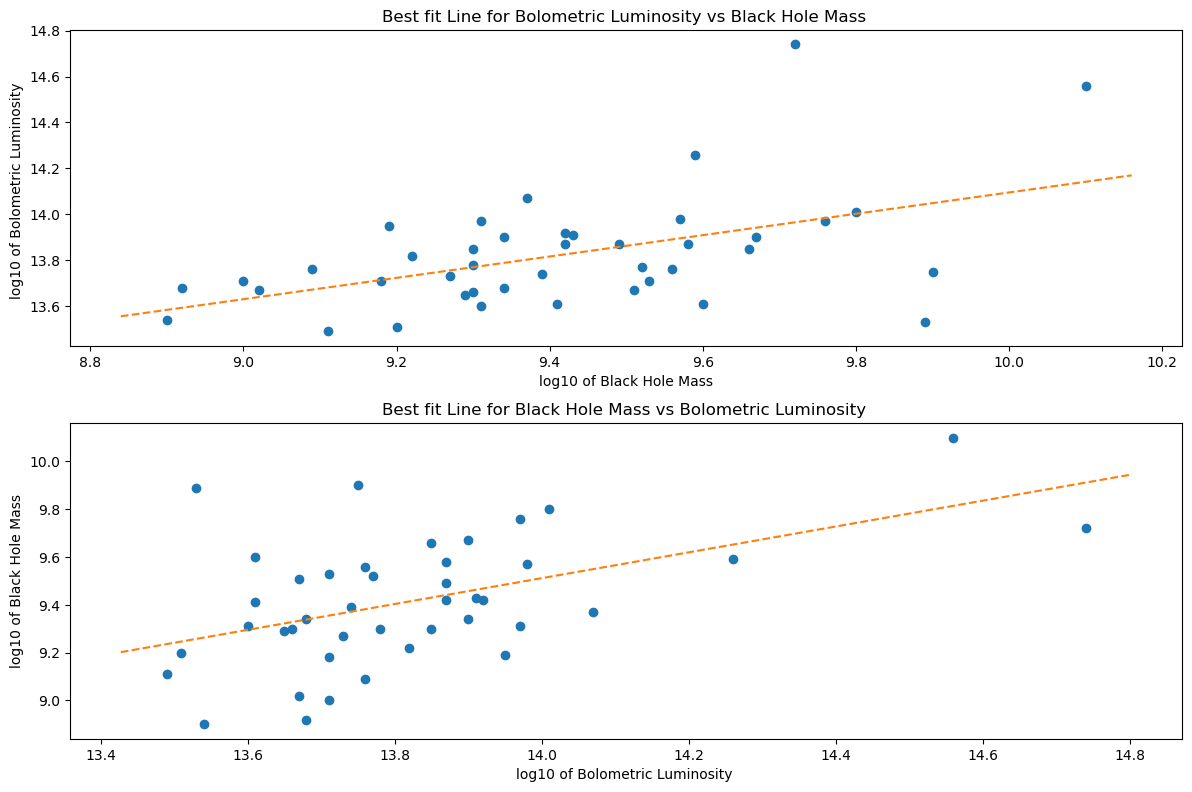

In [2]:
## Problem #1
# Part A
import numpy as np
import scipy 
import statistics
import matplotlib.pyplot as plt

data_filename = "LbolMbh2.dat"
y, x, dy, dx = np.loadtxt(data_filename, unpack = True, skiprows = 0)

slope = scipy.stats.linregress(x,y)[0]
intercept = scipy.stats.linregress(x,y)[1]

# Part B
m = np.cov(x, y)
Var_x = m[0][0]
Var_y = m[1][1]
Cov = m[0][1]
x_bar = statistics.mean(x)
y_bar = statistics.mean(y)
a = Cov / Var_x
b = y_bar - a * x_bar

# Part C
inv_slope = scipy.stats.linregress(y,x)[0]
inv_intercept = scipy.stats.linregress(y,x)[1]

# Part D
fig, ax = plt.subplots(2, 1, figsize = (12,8))

ax[0].plot(x, y,'o')
x_vals = np.array(ax[0].get_xlim())
y_vals = intercept + slope * x_vals
ax[0].plot(x_vals, y_vals, '--') 
ax[0].set_xlabel('log10 of Black Hole Mass')
ax[0].set_ylabel('log10 of Bolometric Luminosity ')
ax[0].set_title('Best fit Line for Bolometric Luminosity vs Black Hole Mass ')

ax[1].plot(y, x,'o')
x1_vals = np.array(ax[1].get_xlim())
y1_vals = inv_intercept + inv_slope * x1_vals
ax[1].plot(x1_vals, y1_vals, '--')
ax[1].set_ylabel('log10 of Black Hole Mass')
ax[1].set_xlabel('log10 of Bolometric Luminosity ')
ax[1].set_title('Best fit Line for Black Hole Mass vs Bolometric Luminosity ')

fig.tight_layout(pad = 1)
plt.show()

## Both best fit lines pass through the 'center' of the data points with some deviating away from the line. Both lines 
# Both lines are of course within the same range except their range of axes are simply flipped
# thus both best fit lines seem to run parallel and with the same slope, as expected. However for BMH vs Luminosity, 
# the data points seem to be more concentrated within a certain region on the x-axis where as for its inverse
# (Luminosity vs BMH) they are more spread out along the x-axis, but as axpected this relation is due to the inverse of axes

<class 'numpy.ndarray'>
[13.53 13.75 13.74 13.68 13.9  13.51 13.95 13.71 13.6  13.76 13.61 13.98
 13.87 13.66 13.92 13.97 13.61 13.82 13.67 13.54 13.77 14.01 13.87 13.67
 13.76 13.68 13.85 13.85 13.9  13.71 14.56 14.07 13.87 13.91 14.74 13.97
 14.26 13.49 13.73 13.65 13.71 13.78]
Converged with chi-squared 1.89
Number of degrees of freedom, dof = 40.00
Reduced chi-squared 0.05

Parameter # | Initial guess values:    | Best fit values:         | Uncertainties in the best fit values:
0           | 0.000e+00                | 9.443e+00                | 5.502e+00               
1           | 1.000e+00                | 4.653e-01                | 5.841e-01               
Converged with chi-squared 2.19
Number of degrees of freedom, dof = 40.00
Reduced chi-squared 0.05

Parameter # | Initial guess values:    | Best fit values:         | Uncertainties in the best fit values:
0           | 0.000e+00                | 1.945e+00                | 8.704e+00               
1           | 1.000e+00     

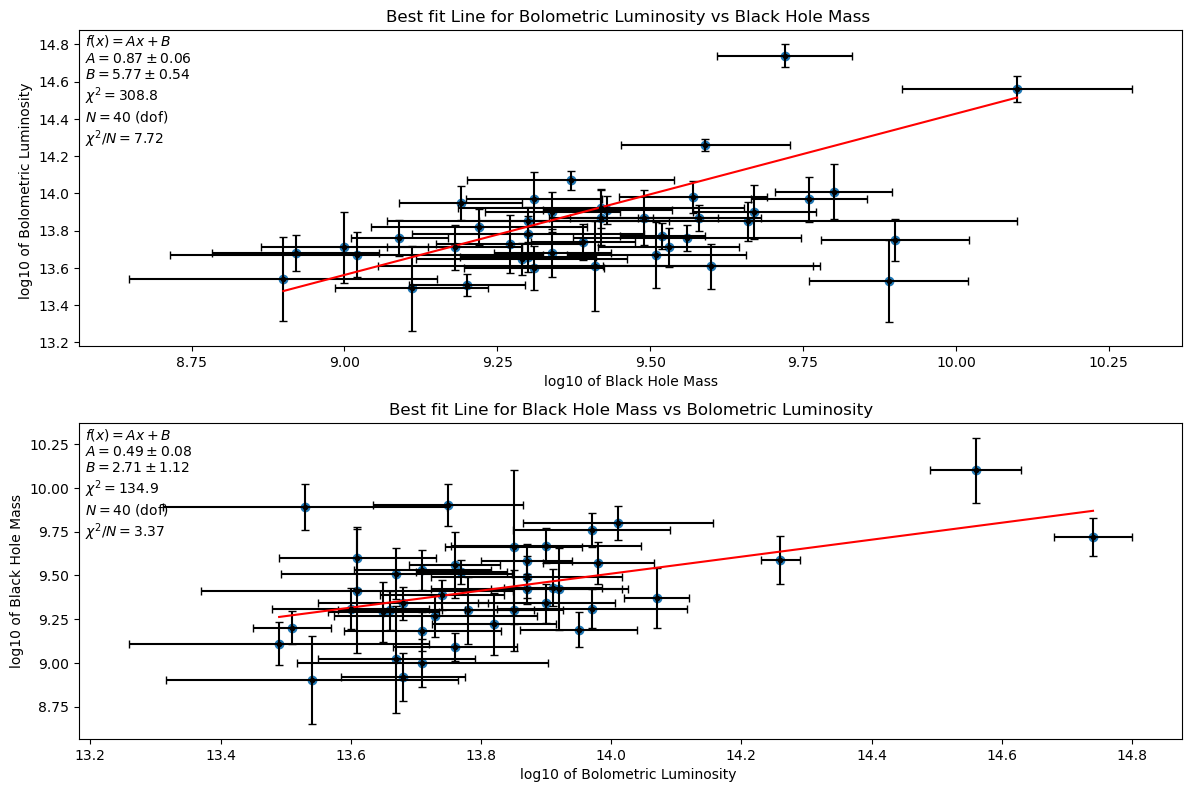

In [3]:
## Problem 2
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy import stats


data_filename = "LbolMbh2.dat"
y, x, dy, dx = np.loadtxt(data_filename, unpack = True, skiprows = 0)

def linear(p, xvar):
    return p[0] + p[1]*xvar
def residual(p,func, xvar, yvar, err):
    return (func(p, xvar) - yvar)/err
def data_fit(p0,func,xvar, yvar, err, tmi=0):
    try:
        fit = optimize.least_squares(residual, p0, args = (func, xvar, yvar, err),verbose=tmi)
    except Exception as error:
        print("Something has gone wrong:",error)
        return p0,np.zeros_like(p0),np.nan,np.nan
    pf = fit['x']

    try:
        cov = np.linalg.inv(fit['jac'].T.dot(fit['jac']))          
    except:
        return pf,np.zeros_like(pf),np.nan,np.nan
    chisq = sum(residual(pf,func,xvar, yvar, err) **2)
    dof = len(xvar) - len(pf)
    red_chisq = chisq/dof
    pferr = np.sqrt(np.diagonal(cov)) # finds the uncertainty in fit parameters by squaring diagonal elements of the covariance matrix
    print('Converged with chi-squared {:.2f}'.format(chisq))
    print('Number of degrees of freedom, dof = {:.2f}'.format(dof))
    print('Reduced chi-squared {:.2f}'.format(red_chisq))
    print()
    Columns = ["Parameter #","Initial guess values:", "Best fit values:", "Uncertainties in the best fit values:"]
    print('{:<11}'.format(Columns[0]),'|','{:<24}'.format(Columns[1]),"|",'{:<24}'.format(Columns[2]),"|",'{:<24}'.format(Columns[3]))
    for num in range(len(pf)):
        print('{:<11}'.format(num),'|','{:<24.3e}'.format(p0[num]),'|','{:<24.3e}'.format(pf[num]),'|','{:<24.3e}'.format(pferr[num]))
    return pf, pferr, chisq, dof
pf, pferr, chisq, dof = data_fit([0,1],linear, x, y, 1)
pf1, pferr1, chisq1, dof1 = data_fit([0,1],linear, y, x, 1)

# Part B

fig, ax = plt.subplots(2, 1, figsize = (12,8))
ax[0].plot(x, y,'o')
ax[0].errorbar(x,y,yerr = dy,xerr = dx,fmt = 'k.',label = 'Errors',capsize = 3)
ax[0].set_xlabel('log10 of Black Hole Mass')
ax[0].set_ylabel('log10 of Bolometric Luminosity ')
ax[0].set_title('Best fit Line for Bolometric Luminosity vs Black Hole Mass ')

ax[1].plot(y, x,'o')
ax[1].errorbar(y,x,yerr = dx,xerr = dy,fmt = 'k.',label = 'Errors',capsize = 3)
ax[1].set_ylabel('log10 of Black Hole Mass')
ax[1].set_xlabel('log10 of Bolometric Luminosity ')
ax[1].set_title('Best fit Line for Black Hole Mass vs Bolometric Luminosity')

# Part C

pf, pferr, chisq, dof = data_fit([0,1],linear, x, y, dy)
inv_pf, inv_pferr, inv_chisq, inv_dof = data_fit([0,1],linear, y, x, dx)

# Part D

x= np.linspace(x.min(),x.max(),500)
ax[0].plot(x, linear(pf, x), 'r-', label = 'Linear Fit: $f(x)$')
textfit = '$f(x) = Ax+B$ \n' 
textfit +='$A = {:.2f} \pm {:.2f}$ \n'.format(pf[1],pferr[1]) 
textfit += '$B = {:.2f} \pm {:.2f}$ \n'.format(pf[0],pferr[0]) 
textfit += '$\chi^2= {:.1f}$ \n'.format(chisq) 
textfit += '$N = {}$ (dof) \n'.format(dof) 
textfit += '$\chi^2/N = {:.2f}$'.format(chisq/dof) 
ax[0].text(0.005, 0.99, textfit, transform = ax[0].transAxes , fontsize = 10, verticalalignment=  'top')

y = np.linspace(y.min(),y.max(),500)
ax[1].plot(y, linear(inv_pf, y), 'r-', label = 'Linear Fit: $f(x)$')
textfit = '$f(x) = Ax+B$ \n' 
textfit +='$A = {:.2f} \pm {:.2f}$ \n'.format(inv_pf[1],inv_pferr[1]) 
textfit += '$B = {:.2f} \pm {:.2f}$ \n'.format(inv_pf[0],inv_pferr[0]) 
textfit += '$\chi^2= {:.1f}$ \n'.format(inv_chisq) 
textfit += '$N = {}$ (dof) \n'.format(inv_dof) 
textfit += '$\chi^2/N = {:.2f}$'.format(inv_chisq/inv_dof) 
ax[1].text(0.005, 0.99, textfit, transform = ax[1].transAxes , fontsize = 10, verticalalignment = 'top')

fig.tight_layout(pad = 1)

# Part E

print(1 - scipy.stats.chi2.cdf(308.83, 40))
print(1 - scipy.stats.chi2.cdf(134.94, 40))

# According to the p-values printed these results are significant as they're less than 0.05, 
# I calculated the degrees of freedom by subtracting the two coefficents of the linear equation, two, and the length 
# of the x and y list resulting in 40 

Converged with chi-squared 1460.55
Number of degrees of freedom, dof = 1046.00
Reduced chi-squared 1.40

Parameter # | Initial guess values:    | Best fit values:         | Uncertainties in the best fit values:
0           | 0.000e+00                | 3.768e+00                | 1.597e-03               
1           | 1.000e+00                | 1.103e+00                | 1.873e-03               
1.1026823633585114 3.767681684522422 1460.5540933291961 3.3306690738754696e-16 51.184487002880715
Converged with chi-squared 1029.19
Number of degrees of freedom, dof = 1044.00
Reduced chi-squared 0.99

Parameter # | Initial guess values:    | Best fit values:         | Uncertainties in the best fit values:
0           | 0.000e+00                | 3.641e+00                | 9.532e-03               
1           | 1.000e+00                | 1.014e+00                | 6.331e-03               
2           | 2.000e+00                | 6.437e-01                | 6.618e-02               
3           | 3

C:\Users\barre\AppData\Local\Temp\ipykernel_20420\788936262.py:64: RuntimeWarning: invalid value encountered in log10
  return p[0] + p[1] * np.log10(xvar) + np.log10(1 + (p[2] * xvar) + (p[3] * (xvar ** 2)))


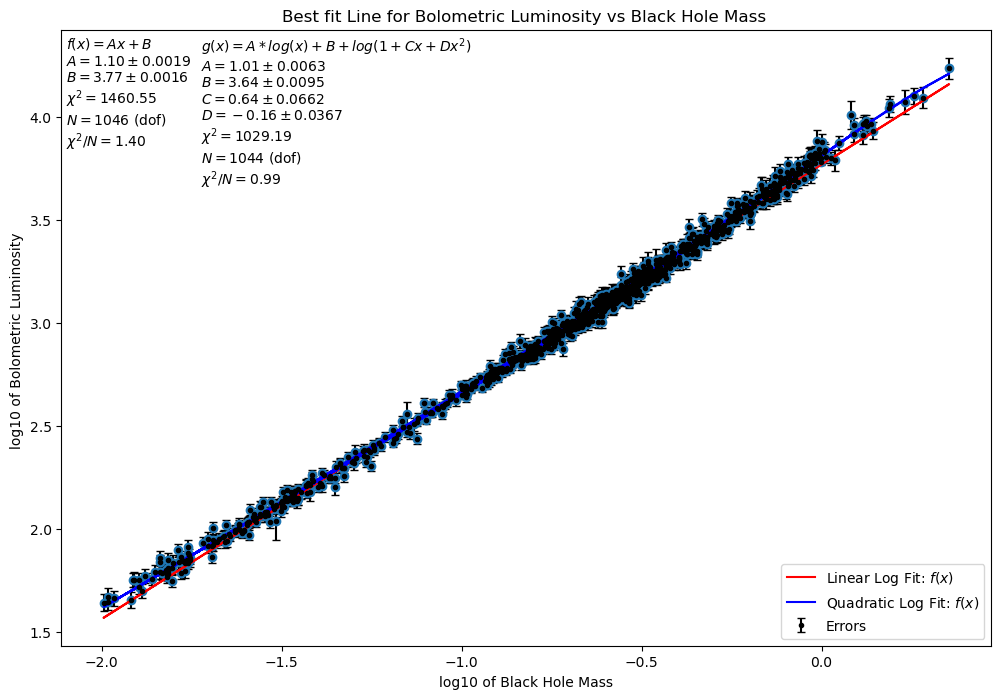

In [4]:
## Problem 5
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy import stats

# Part A
filename = "hlsp_ps1cosmo_panstarrs_gpc1_all_model_v1_lcparam-full.txt"
zcmb, zhel, dz, mb, dmb = np.loadtxt(filename, unpack = True, skiprows = 1, usecols = (1,2,3,4,5))
Dis_lst = []
for x in mb:
    D = (10 ** ((x + 24.3) / 5)) / 1000000
    Dis_lst.append(D)
dDis_lst = []
for i in range(0, len(dmb)):
    dD = 2.303 * dmb[i] * Dis_lst[i] / 5
    dDis_lst.append(dD)
    
y = np.log10(Dis_lst)
x = np.log10(zcmb)
dy = []
for i in range (0, len(dDis_lst)):
    dyy = (0.4343 * dDis_lst[i]) / Dis_lst[i]
    dy.append(dyy)

fig, ax = plt.subplots(figsize = (12,8))
ax.errorbar(x, y, dy, fmt = 'k.', label = 'Errors',capsize = 3)
ax.plot(x, y, 'o' )

ax.set_xlabel('log10 of Black Hole Mass')
ax.set_ylabel('log10 of Bolometric Luminosity ')
ax.set_title('Best fit Line for Bolometric Luminosity vs Black Hole Mass ')

# Part B
# Find the best fit slope a and intercept b = log10(c/H0) for the linear relation between
# y and x. Also compute the values for χ
# 2 and its p-value. Finally, compute the value of the
# Hubble constant H0 in km/s/Mpc from the value of the intercept.

pf, pferr, chisq, dof = data_fit([0,1],linear, x, y, dy)
p_val = 1 - scipy.stats.chi2.cdf(1460.55, 1046)
slope = pf[1]
intercept = pf[0]
H_con = 299792 / (10 ** intercept)
print(slope, intercept, chisq, p_val, H_con)

# Part C

ax.plot(x, linear(pf, x), 'r-', label = 'Linear Log Fit: $f(x)$')
textfit = '$f(x) = Ax+B$ \n' 
textfit +='$A = {:.2f} \pm {:.4f}$ \n'.format(pf[1],pferr[1]) 
textfit += '$B = {:.2f} \pm {:.4f}$ \n'.format(pf[0],pferr[0]) 
textfit += '$\chi^2= {:.2f}$ \n'.format(chisq) 
textfit += '$N = {}$ (dof) \n'.format(dof) 
textfit += '$\chi^2/N = {:.2f}$'.format(chisq/dof) 
ax.text(0.005, 0.99, textfit, transform = ax.transAxes , fontsize = 10, verticalalignment=  'top')

# Part D
# y = b + a log10(z)  + log10(1 + Cz + Dz2), where C and D are sometimes called ”nuisance” parameters, 
# they are only needed to improve the fit, but are not interesting by themselves (unless you care about the dark energy!). 
# Plot the new best-fit on the same plot from (A), and report the value for χ its p-value, and the best-fit value for H0.

def fit_func(p, xvar):
    return p[0] + p[1] * np.log10(xvar) + np.log10(1 + (p[2] * xvar) + (p[3] * (xvar ** 2)))

pf, pferr, chisq, dof = data_fit([0,1,2,3],fit_func, zcmb, y, dy)

ax.plot(x, fit_func(pf, zcmb), 'b-', label = 'Quadratic Log Fit: $f(x)$')
textfit = '$g(x) = A*log(x)+B + log(1+Cx+Dx^2)$ \n' 
textfit +='$A = {:.2f} \pm {:.4f}$ \n'.format(pf[1],pferr[1]) 
textfit += '$B = {:.2f} \pm {:.4f}$ \n'.format(pf[0],pferr[0]) 
textfit += '$C = {:.2f} \pm {:.4f}$ \n'.format(pf[2],pferr[2]) 
textfit += '$D = {:.2f} \pm {:.4f}$ \n'.format(pf[3],pferr[3]) 
textfit += '$\chi^2= {:.2f}$ \n'.format(chisq) 
textfit += '$N = {}$ (dof) \n'.format(dof) 
textfit += '$\chi^2/N = {:.2f}$'.format(chisq/dof) 
ax.text(0.15, 0.99, textfit, transform = ax.transAxes , fontsize = 10, verticalalignment=  'top')
ax.legend(loc = 'lower right')

chisqmin = chisq

p_val = 1 - scipy.stats.chi2.cdf(1029.19, 1044)
H_con1 = 299792 / (10 ** pf[0])
print(chisq, p_val, H_con1)

print(H_con,H_con1)

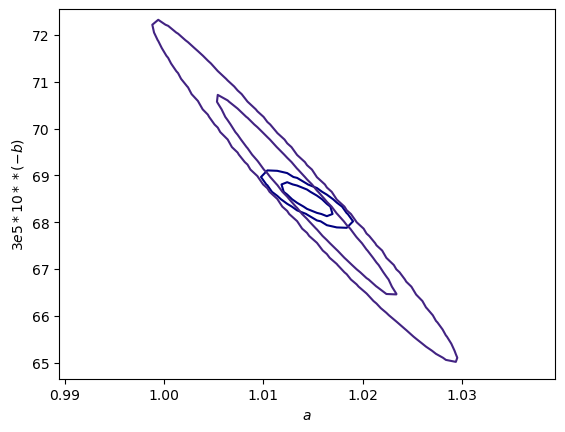

In [18]:
# Part E

def residual1(p, a, b, func, xvar, yvar, err):
    return (func(p, a, b, xvar) - yvar)/err
def fit_func1(p,a,b, xvar):
    return a + b * np.log10(xvar) + np.log10(1 + (p[0] * xvar) + (p[1] * (xvar ** 2)))
def data_fit1(a,b,p0, func, xvar,yvar, err, tmi=0):
    try:
        fit = optimize.least_squares(residual1, p0, args = (a, b, func, xvar, yvar, err), verbose=tmi)
    except Exception as error:
        print("Something has gone wrong:",error)
        return p0,np.zeros_like(p0),np.nan,np.nan
    pf = fit['x']
    chisq = sum(residual1(pf,a,b,func,xvar, yvar, err) **2)
    dof = len(xvar) - len(pf)
    red_chisq = chisq/dof
    return pf,pferr,chisq, dof

a0 = pf[1]
b0 = pf[0]
da = 0.05
db = 0.05
N = 100

tv = [1,1]
xvals = np.zeros((N + 1,N + 1))
yvals = np.zeros((N + 1,N + 1))
pvals = np.zeros((N + 1,N + 1))

for i1 in range(N + 1):
    tv[1] = b0 + db/N * (i1 - (N / 2))
    for i0 in range(N + 1):
        tv[0] = a0 + da/N * (i0 - (N / 2))
        xvals[i0,i1] = tv[0]
        yvals[i0,i1] = tv[1]
        p1 = [tv[1], tv[0], pf[2], pf[3]]
        chisq = sum(residual(p1, fit_func, zcmb, y, dy) ** 2)
        dchisq = chisq - chisqmin
        pvals[i0,i1] =  1 - scipy.stats.chi2.cdf(dchisq, 2)
        
# Part F

pvals1 = np.zeros((N + 1,N + 1))

for i1 in range(N + 1):
    for i0 in range(N + 1):
        pf1,pferr, chisq1, dof1 = data_fit1(yvals[i0,i1], xvals[i0,i1],[pf[2], pf[3]], fit_func1, zcmb, y, dy)
        dchisq1 = chisq1 - chisqmin
        pvals1[i0, i1] =  1 - scipy.stats.chi2.cdf(dchisq1, 2)
        H_con1 = 299792 / (10 ** pf[0])
        
fig, ax = plt.subplots()
ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$3e5*10**(-b) $")
ax.contour(xvals, 3e5 * 10 ** (-yvals), pvals, levels = [0.05, 0.35], colors = "#000080")
ax.contour(xvals, 3e5 * 10 ** (-yvals), pvals1, levels = [0.05, 0.35], colors = "#422382")

[[72.49966386 72.33291926 72.16655816 ... 64.91364454 64.7643473
  64.61539343]
 [72.49966386 72.33291926 72.16655816 ... 64.91364454 64.7643473
  64.61539343]
 [72.49966386 72.33291926 72.16655816 ... 64.91364454 64.7643473
  64.61539343]
 ...
 [72.49966386 72.33291926 72.16655816 ... 64.91364454 64.7643473
  64.61539343]
 [72.49966386 72.33291926 72.16655816 ... 64.91364454 64.7643473
  64.61539343]
 [72.49966386 72.33291926 72.16655816 ... 64.91364454 64.7643473
  64.61539343]]


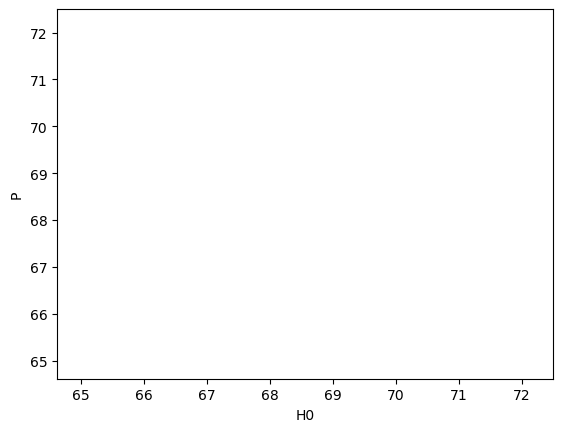

In [19]:
# Part G Let’s go back to standard cosmology, a = 1, and actually measure H0. Plot the distribution of χ2-values 
# for H0 vs H0 with marginalization over C and D and report 1σ and 2σ errors on H0 
# (report them in this form: ”H0 = 70 + 2.5 − 2.8 km/s/Mpc”).

pvals2 = np.zeros((N + 1,N + 1))
H0 = np.zeros((N + 1,N + 1))
for i1 in range(N + 1):
    for i0 in range(N + 1):
        pf1,pferr, chisq1, dof1 = data_fit1(yvals[i0,i1], 1,[pf[2],pf[3]], fit_func1, zcmb, y, dy)
        dchisq1 = chisq1 - chisqmin
        pvals1[i0, i1] =  1 - scipy.stats.chi2.cdf(dchisq1, 2)
        h = 299792 / (10 ** yvals[i0,i1])
        H0[i0,i1] = h
        
print(H0)
# plt.plot(pvals2, H0[2])
plt.contour(H0,H0,pvals2,levels=[0.05,0.35],colors="b")
plt.xlabel('H0')
plt.ylabel('P')
plt.show()

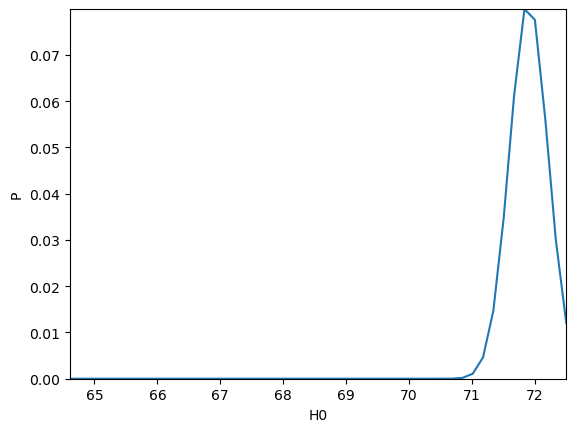

In [24]:
# Part G Let’s go back to standard cosmology, a = 1, and actually measure H0. Plot the distribution of χ2-values 
# for H0 vs H0 with marginalization over C and D and report 1σ and 2σ errors on H0 
# (report them in this form: ”H0 = 70 + 2.5 − 2.8 km/s/Mpc”).

pvals2 =[]
H0 = []
for i1 in range(N + 1):
    for i0 in range(N + 1):
        pf1,pferr, chisq1, dof1 = data_fit1(yvals[i0,i1], 1,[pf[2],pf[3]], fit_func1, zcmb, y, dy)
        dchisq1 = chisq1 - chisqmin
        pvals2.append(1 - scipy.stats.chi2.cdf(dchisq1, 2)) 
        h = 299792 / (10 ** yvals[i0,i1])
        H0.append(h)
        
# plt.plot(pvals2, H0[2])
# plt.contour(H0,H0,pvals2,levels=[0.05,0.35],colors="b")
plt.plot(H0,pvals2)
plt.xlim(min(H0), max(H0))
plt.ylim(min(pvals2), max(pvals2))
plt.xlabel('H0')
plt.ylabel('P')
plt.show()